In [ ]:
# @hidden_cell
# The project token is an authorization token that is used to access project resources like data sources, connections, and used by platform APIs.
from project_lib import Project
project = Project(project_id='087382f3-1105-4c96-9b0b-0f11abcb7e7b', project_access_token='YOUR_PROJECT_ACCESS_TOKEN')
pc = project.project_context

from ibm_watson_studio_lib import access_project_or_space
wslib = access_project_or_space({'token':'YOUR_PROJECT_ACCESS_TOKEN'})
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully")

Libraries imported successfully


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


In [9]:
# 1. Change the extension to .csv
file = wslib.load_data("predictive_maintenance.csv") 

# 2. Change read_excel to read_csv
df = pd.read_csv(file)

# 3. View the data
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [10]:
df.shape

(10000, 10)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [12]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

In [13]:
df["Failure Type"].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

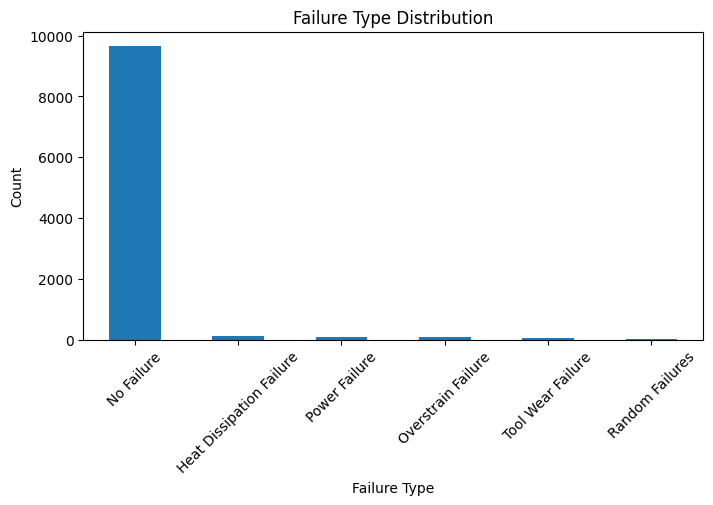

In [14]:
plt.figure(figsize=(8,4))
df["Failure Type"].value_counts().plot(kind="bar")
plt.title("Failure Type Distribution")
plt.xlabel("Failure Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [15]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [16]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='object')

In [17]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

le_type = LabelEncoder()
le_failure = LabelEncoder()

df_model["Type"] = le_type.fit_transform(df_model["Type"])
df_model["Failure Type"] = le_failure.fit_transform(df_model["Failure Type"])

df_model.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,2,298.1,308.6,1551,42.8,0,0,1
1,2,L47181,1,298.2,308.7,1408,46.3,3,0,1
2,3,L47182,1,298.1,308.5,1498,49.4,5,0,1
3,4,L47183,1,298.2,308.6,1433,39.5,7,0,1
4,5,L47184,1,298.2,308.7,1408,40.0,9,0,1


In [18]:
X = df_model.drop(["UDI", "Product ID", "Target", "Failure Type"], axis=1)
y = df_model["Failure Type"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 6)
Target shape: (10000,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 6)
Testing data: (2000, 6)


In [20]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Model training completed successfully")

Model training completed successfully


In [21]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9815


In [22]:
print(classification_report(y_test, y_pred, target_names=le_failure.classes_))

                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      0.82      0.90        22
              No Failure       0.98      1.00      0.99      1930
      Overstrain Failure       1.00      0.50      0.67        16
           Power Failure       0.89      0.42      0.57        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.98      2000
               macro avg       0.65      0.46      0.52      2000
            weighted avg       0.97      0.98      0.98      2000



/opt/user-env/pyt6/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/user-env/pyt6/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/user-env/pyt6/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
print(classification_report(y_test, y_pred, target_names=le_failure.classes_, zero_division=0))

                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      0.82      0.90        22
              No Failure       0.98      1.00      0.99      1930
      Overstrain Failure       1.00      0.50      0.67        16
           Power Failure       0.89      0.42      0.57        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.98      2000
               macro avg       0.65      0.46      0.52      2000
            weighted avg       0.97      0.98      0.98      2000



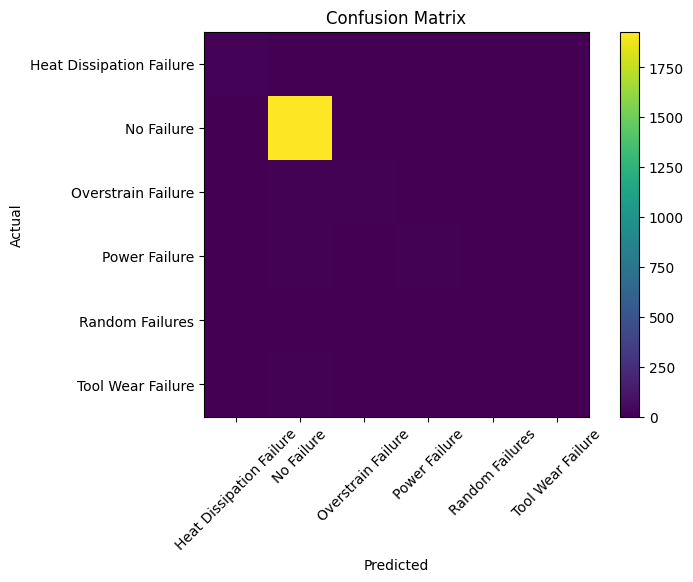

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.xticks(range(len(le_failure.classes_)), le_failure.classes_, rotation=45)
plt.yticks(range(len(le_failure.classes_)), le_failure.classes_)
plt.show()

In [25]:
import joblib

joblib.dump(model, "predictive_maintenance_model.pkl")
joblib.dump(le_type, "type_encoder.pkl")
joblib.dump(le_failure, "failure_encoder.pkl")

print("Model and encoders saved successfully")

Model and encoders saved successfully


In [26]:
sample_input = X_test.iloc[0:1]

prediction = model.predict(sample_input)

predicted_failure = le_failure.inverse_transform(prediction)

print("Predicted Failure Type:", predicted_failure[0])

Predicted Failure Type: No Failure


In [27]:
failure_sample = df[df["Failure Type"] != "No Failure"].head(1)

failure_sample

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
50,51,L47230,L,298.9,309.1,2861,4.6,143,1,Power Failure


In [28]:
failure_sample_model = failure_sample.copy()

failure_sample_model["Type"] = le_type.transform(failure_sample_model["Type"])

sample_X = failure_sample_model.drop(["UDI", "Product ID", "Target", "Failure Type"], axis=1)

prediction = model.predict(sample_X)

predicted_failure = le_failure.inverse_transform(prediction)

print("Actual Failure Type:", failure_sample["Failure Type"].values[0])
print("Predicted Failure Type:", predicted_failure[0])

Actual Failure Type: Power Failure
Predicted Failure Type: Power Failure


In [29]:
import pandas as pd

new_machine = pd.DataFrame({
    "Type": le_type.transform(["L"]),
    "Air temperature [K]": [298.1],
    "Process temperature [K]": [308.6],
    "Rotational speed [rpm]": [1551],
    "Torque [Nm]": [42.8],
    "Tool wear [min]": [0]
})

prediction = model.predict(new_machine)
predicted_failure = le_failure.inverse_transform(prediction)

print("Predicted Failure Type:", predicted_failure[0])

Predicted Failure Type: No Failure


In [30]:
df[df["Failure Type"] != "No Failure"].head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
50,51,L47230,L,298.9,309.1,2861,4.6,143,1,Power Failure
69,70,L47249,L,298.9,309.0,1410,65.7,191,1,Power Failure
77,78,L47257,L,298.8,308.9,1455,41.3,208,1,Tool Wear Failure
160,161,L47340,L,298.4,308.2,1282,60.7,216,1,Overstrain Failure
161,162,L47341,L,298.3,308.1,1412,52.3,218,1,Overstrain Failure


In [31]:
failure_row = df[df["Failure Type"] != "No Failure"].iloc[0]

failure_row

UDI                                   51
Product ID                        L47230
Type                                   L
Air temperature [K]                298.9
Process temperature [K]            309.1
Rotational speed [rpm]              2861
Torque [Nm]                          4.6
Tool wear [min]                      143
Target                                 1
Failure Type               Power Failure
Name: 50, dtype: object

In [32]:
failure_row_model = failure_row.copy()

failure_row_model["Type"] = le_type.transform([failure_row_model["Type"]])[0]

sample_X = pd.DataFrame([failure_row_model]).drop(
    ["UDI", "Product ID", "Target", "Failure Type"], axis=1
)

prediction = model.predict(sample_X)
predicted_failure = le_failure.inverse_transform(prediction)

print("Actual Failure Type:", failure_row["Failure Type"])
print("Predicted Failure Type:", predicted_failure[0])

Actual Failure Type: Power Failure
Predicted Failure Type: Power Failure


In [33]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
5,Tool wear [min],0.275203
4,Torque [Nm],0.272362
3,Rotational speed [rpm],0.211538
1,Air temperature [K],0.126205
2,Process temperature [K],0.091693
0,Type,0.022999


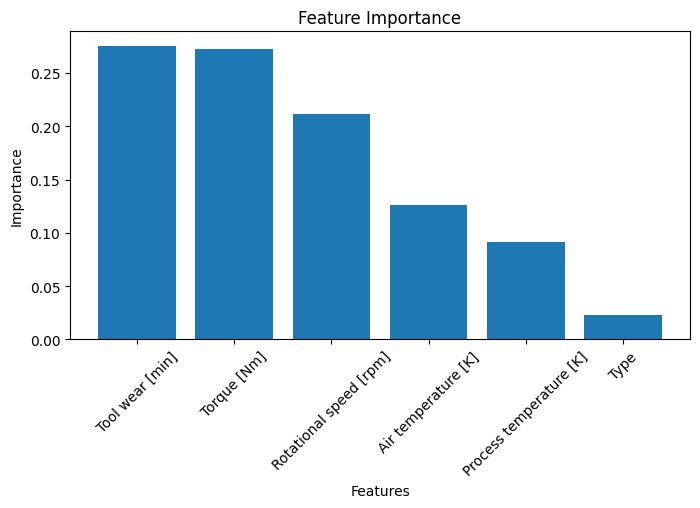

In [34]:
plt.figure(figsize=(8,4))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [35]:
print("Project Summary")
print("Dataset rows and columns:", df.shape)
print("Model used: Random Forest Classifier")
print("Accuracy:", accuracy)
print("Most important feature:", feature_importance.iloc[0]["Feature"])

Project Summary
Dataset rows and columns: (10000, 10)
Model used: Random Forest Classifier
Accuracy: 0.9815
Most important feature: Tool wear [min]


In [36]:
wslib.save_data("predictive_maintenance_model.pkl", open("predictive_maintenance_model.pkl", "rb"), overwrite=True)
wslib.save_data("type_encoder.pkl", open("type_encoder.pkl", "rb"), overwrite=True)
wslib.save_data("failure_encoder.pkl", open("failure_encoder.pkl", "rb"), overwrite=True)

print("Model files saved to IBM project assets successfully")

RuntimeError: Argument "data" must be a bytes-like object. Use str.encode() to convert character data.

In [3]:
# Append .read() to extract the raw bytes from the file stream
wslib.save_data("predictive_maintenance_model.pkl", open("predictive_maintenance_model.pkl", "rb").read(), overwrite=True)
wslib.save_data("type_encoder.pkl", open("type_encoder.pkl", "rb").read(), overwrite=True)
wslib.save_data("failure_encoder.pkl", open("failure_encoder.pkl", "rb").read(), overwrite=True)

print("Model files saved to IBM project assets successfully")


RuntimeError: No matching attachment in "type_encoder.pkl" (019e9669-5c6c-72d3-a2d2-43f077920777).

In [4]:
wslib.save_data("predictive_maintenance_model_final.pkl", open("predictive_maintenance_model.pkl", "rb").read(), overwrite=True)
wslib.save_data("type_encoder_final.pkl", open("type_encoder.pkl", "rb").read(), overwrite=True)
wslib.save_data("failure_encoder_final.pkl", open("failure_encoder.pkl", "rb").read(), overwrite=True)

print("Final model and encoder files saved successfully")

Final model and encoder files saved successfully


In [1]:
import sklearn
import sys

print("Python version:", sys.version)
print("Scikit-learn version:", sklearn.__version__)

Python version: 3.12.13 (main, Apr 16 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-14)]
Scikit-learn version: 1.6.1


In [2]:
import ibm_watsonx_ai

print("ibm_watsonx_ai installed successfully")

ibm_watsonx_ai installed successfully


In [3]:
from ibm_watsonx_ai import APIClient

print("Ready for Watson Machine Learning setup")

Ready for Watson Machine Learning setup


In [4]:
from ibm_watsonx_ai import APIClient, Credentials
import os

print("Next we need your IBM Cloud region and deployment space ID")

Next we need your IBM Cloud region and deployment space ID


In [5]:
print("Model exists:", model)
print("X columns:", list(X.columns))
print("Target classes:", le_failure.classes_)

NameError: name 'model' is not defined

In [6]:
from ibm_watson_studio_lib import access_project_or_space
wslib = access_project_or_space(...)

AttributeError: 'ellipsis' object has no attribute 'get'

In [ ]:
from ibm_watson_studio_lib import access_project_or_space

wslib = access_project_or_space({
    "token": "YOUR_PROJECT_TOKEN",
    "project_id": "YOUR_PROJECT_ID"
})

In [8]:
print("wslib ready")
print(type(wslib))

wslib ready
<class 'ibm_watson_studio_lib.impl.agent.Agent'>


In [9]:
SPACE_ID = "def5c3a9-1d49-4668-a45f-5db938b91f5"

print("Space ID saved:", SPACE_ID)

Space ID saved: def5c3a9-1d49-4668-a45f-5db938b91f5


In [ ]:
API_KEY= "API_KEY"
print("API key saved")

API key saved


In [11]:
from ibm_watsonx_ai import APIClient, Credentials

credentials = Credentials(
    url="https://au-syd.ml.cloud.ibm.com",
    api_key=API_KEY
)

client = APIClient(credentials)
client.set.default_space(SPACE_ID)

print("Connected to Watson Machine Learning deployment space successfully")

Cannot set Project or Space
Reason: Space with id 'def5c3a9-1d49-4668-a45f-5db938b91f5' does not exist


CannotSetProjectOrSpace: Cannot set Project or Space
Reason: Space with id 'def5c3a9-1d49-4668-a45f-5db938b91f5' does not exist

In [12]:
from ibm_watsonx_ai import APIClient, Credentials

credentials = Credentials(
    url="https://au-syd.ml.cloud.ibm.com",
    api_key=API_KEY
)

client = APIClient(credentials)
client.set.default_space(SPACE_ID)

print("Connected to Watson Machine Learning deployment space successfully")

Cannot set Project or Space
Reason: Space with id 'def5c3a9-1d49-4668-a45f-5db938b91f5' does not exist


CannotSetProjectOrSpace: Cannot set Project or Space
Reason: Space with id 'def5c3a9-1d49-4668-a45f-5db938b91f5' does not exist

In [13]:
SPACE_ID = "def5c3a9-1d49-4668-a45f-50db938b91f5"

print("Correct Space ID:", SPACE_ID)

Correct Space ID: def5c3a9-1d49-4668-a45f-50db938b91f5


In [14]:
from ibm_watsonx_ai import APIClient, Credentials

credentials = Credentials(
    url="https://au-syd.ml.cloud.ibm.com",
    api_key=API_KEY
)

client = APIClient(credentials)
client.set.default_space(SPACE_ID)

print("Connected to Watson Machine Learning deployment space successfully")

Connected to Watson Machine Learning deployment space successfully


In [15]:
client.software_specifications.list()

,NAME,ID,TYPE,STATE,REPLACEMENT
0,runtime-25.1-py3.12-xc,0144ea5e-9ff3-579a-9888-e252f75d24fa,base,supported,
1,autoai-kb_rt25.1-py3.12,046f5252-0d07-5c23-81ef-18a1a31cdce3,base,supported,
2,watsonx-textgen-fm-1.0,129aec82-7e65-5c78-b812-4c0a74b916f5,base,supported,
3,masking-flows-spark,13666829-5570-53a7-927b-52d42a101d93,base,supported,
4,autoai-ts_rt25.1-py3.12,1c0c9e1d-8523-520f-867e-102173f16f5e,base,supported,
5,autoai-rag_ai25a-py3.12,29e710a0-5a09-5ae7-a4aa-4cd8e4eaca8c,base,supported,
6,runtime-25.1-r4.4,2b2ddb1d-6c0f-5b95-9d04-3056270ea5c6,base,supported,
7,kernel-spark3.5-py3.11,30ad99e2-7cfb-511a-9a3e-4cc308071fd3,base,supported,
8,kernel-spark3.5-r4.3,3668b4d5-b8b8-5926-badf-1134137613d4,base,supported,
9,onnxruntime_opset_19,368d2795-aaa7-59a0-834c-248c64a5a99e,base,supported,


In [16]:
import joblib

model = joblib.load("predictive_maintenance_model.pkl")

print("Model loaded successfully")
print(model)

FileNotFoundError: [Errno 2] No such file or directory: 'predictive_maintenance_model.pkl'

In [17]:
import joblib

model_file = wslib.load_data("predictive_maintenance_model_final.pkl")
model = joblib.load(model_file)

print("Model loaded successfully")
print(model)

failed POST https://api.au-syd.dai.cloud.ibm.com/v2/asset_types/data_asset/search?project_id=087382f3-1105-4c96-9b0b-0f11abcb7e7b, exp: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))


ConnectionError: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

df_model = df.copy()

le_type = LabelEncoder()
le_failure = LabelEncoder()

df_model["Type"] = le_type.fit_transform(df_model["Type"])
df_model["Failure Type"] = le_failure.fit_transform(df_model["Failure Type"])

X = df_model.drop(["UDI", "Product ID", "Target", "Failure Type"], axis=1)
y = df_model["Failure Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model retrained successfully")
print("Accuracy:", accuracy)

NameError: name 'df' is not defined

In [19]:
# Load dataset again from IBM project assets
file = wslib.load_data("predictive_maintenance.csv")

df = pd.read_csv(file)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df_model = df.copy()

le_type = LabelEncoder()
le_failure = LabelEncoder()

df_model["Type"] = le_type.fit_transform(df_model["Type"])
df_model["Failure Type"] = le_failure.fit_transform(df_model["Failure Type"])

X = df_model.drop(["UDI", "Product ID", "Target", "Failure Type"], axis=1)
y = df_model["Failure Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model retrained successfully")
print("Accuracy:", accuracy)

Model retrained successfully
Accuracy: 0.9815


In [21]:
software_spec_uid = client.software_specifications.get_id_by_name("runtime-25.1-py3.12")

model_props = {
    client.repository.ModelMetaNames.NAME: "predictive_maintenance_rf_model",
    client.repository.ModelMetaNames.TYPE: "scikit-learn_1.6",
    client.repository.ModelMetaNames.SOFTWARE_SPEC_UID: software_spec_uid
}

stored_model_details = client.repository.store_model(
    model=model,
    meta_props=model_props,
    training_data=X_train,
    training_target=y_train
)

model_id = client.repository.get_model_id(stored_model_details)

print("Model stored successfully")
print("Model ID:", model_id)

Model stored successfully
Model ID: 019e989c-72fa-72a6-a220-dda7b322bfd3


/opt/user-env/pyt6/lib64/python3.12/site-packages/ibm_watsonx_ai/wml_resource.py:100: WatsonxAPIWarning: online_url and serving_urls are deprecated and will be removed in a future release. Use inference instead.
ID: Deprecated
  warn(cls._build_warning_message(warning), WatsonxAPIWarning)
/opt/user-env/pyt6/lib64/python3.12/site-packages/ibm_watsonx_ai/wml_resource.py:100: WatsonxAPIWarning: online_url and serving_urls are deprecated and will be removed in a future release. Use inference instead.
ID: Deprecated
  warn(cls._build_warning_message(warning), WatsonxAPIWarning)
/opt/user-env/pyt6/lib64/python3.12/site-packages/ibm_watsonx_ai/wml_resource.py:100: WatsonxAPIWarning: online_url and serving_urls are deprecated and will be removed in a future release. Use inference instead.
ID: Deprecated
  warn(cls._build_warning_message(warning), WatsonxAPIWarning)
/opt/user-env/pyt6/lib64/python3.12/site-packages/ibm_watsonx_ai/wml_resource.py:100: WatsonxAPIWarning: online_url and serving_ur

In [22]:
deployment_props = {
    client.deployments.ConfigurationMetaNames.NAME: "predictive_maintenance_online_deployment",
    client.deployments.ConfigurationMetaNames.ONLINE: {}
}

deployment_details = client.deployments.create(
    artifact_uid=model_id,
    meta_props=deployment_props
)

deployment_id = client.deployments.get_id(deployment_details)

print("Deployment created successfully")
print("Deployment ID:", deployment_id)



######################################################################################

Synchronous deployment creation for id: '019e989c-72fa-72a6-a220-dda7b322bfd3' started

######################################################################################


initializing
Note: online_url and serving_urls are deprecated and will be removed in a future release. Use inference instead.
..
ready


-----------------------------------------------------------------------------------------------
Successfully finished deployment creation, deployment_id='019e989e-60a5-7572-9f98-b77fd837350a'
-----------------------------------------------------------------------------------------------


Deployment created successfully
Deployment ID: 019e989e-60a5-7572-9f98-b77fd837350a


In [23]:
deployment_details = client.deployments.get_details(deployment_id)

deployment_details

Note: online_url and serving_urls are deprecated and will be removed in a future release. Use inference instead.


{'entity': {'asset': {'id': '019e989c-72fa-72a6-a220-dda7b322bfd3'},
  'chat_enabled': False,
  'custom': {},
  'deployed_asset_type': 'model',
  'hardware_spec': {'name': 'S', 'num_nodes': 1},
  'online': {},
  'status': {'inference': [{'url': 'https://au-syd.ml.cloud.ibm.com/ml/v4/deployments/019e989e-60a5-7572-9f98-b77fd837350a/predictions'}],
   'online_url': {'url': 'https://au-syd.ml.cloud.ibm.com/ml/v4/deployments/019e989e-60a5-7572-9f98-b77fd837350a/predictions'},
   'serving_urls': ['https://au-syd.ml.cloud.ibm.com/ml/v4/deployments/019e989e-60a5-7572-9f98-b77fd837350a/predictions'],
   'state': 'ready'}},
 'metadata': {'created_at': '2026-06-05T16:29:36.326Z',
  'id': '019e989e-60a5-7572-9f98-b77fd837350a',
  'modified_at': '2026-06-05T16:29:36.326Z',
  'name': 'predictive_maintenance_online_deployment',
  'owner': 'IBMid-691001MHU2',
  'space_id': 'def5c3a9-1d49-4668-a45f-50db938b91f5'},
 'system': {'warnings': [{'id': 'Deprecated',
    'message': 'online_url and serving_url

In [24]:
sample_payload = {
    client.deployments.ScoringMetaNames.INPUT_DATA: [
        {
            "fields": list(X.columns),
            "values": [
                [0, 298.1, 308.6, 1551, 42.8, 0]
            ]
        }
    ]
}

prediction = client.deployments.score(deployment_id, sample_payload)

prediction

{'predictions': [{'fields': ['prediction', 'probability'],
   'values': [[1, [0.0, 1.0, 0.0, 0.0, 0.0, 0.0]]]}]}

In [25]:
predicted_class = prediction["predictions"][0]["values"][0][0]

actual_failure_name = le_failure.inverse_transform([predicted_class])[0]

print("Predicted Failure Type:", actual_failure_name)

Predicted Failure Type: No Failure
